###**AI Adoption and Its Impact on Workforce Productivity**
> Kreisna Witanto | Juny 2026



In [56]:
#Import Libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")

#Load Dataset
df = pd.read_csv("ai_job_impact_clean.csv", sep=";")

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Employee_ID            2000 non-null   object 
 1   Age                    2000 non-null   int64  
 2   Gender                 2000 non-null   object 
 3   Education_Level        2000 non-null   object 
 4   Industry               2000 non-null   object 
 5   Job_Role               2000 non-null   object 
 6   Years_Experience       2000 non-null   int64  
 7   Experience_Group       2000 non-null   object 
 8   AI_Adoption_Level      2000 non-null   object 
 9   Automation_Risk        2000 non-null   object 
 10  Upskilling_Required    2000 non-null   object 
 11  Salary_Before_AI       2000 non-null   int64  
 12  Salary_After_AI        2000 non-null   int64  
 13  Salary_Change_%        2000 non-null   int64  
 14  Salary_Change_%_Raw    2000 non-null   object 
 15  Job_

###**Q1: How is AI adoption distributed across different industries and job roles?**




In [ ]:
#1A :  How is AI adoption distributed across different industries
# Percentage Distribution
industry_percent = (
    pd.crosstab(
        df["Industry"],
        df["AI_Adoption_Level"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

# Reorder columns
industry_percent = industry_percent[["Low", "Medium", "High"]]

# Sort by High AI Adoption (Descending)
industry_percent = industry_percent.sort_values(by="High", ascending=False)

# Format as percentage
industry_percent = industry_percent.astype(str) + "%"

industry_percent

AI_Adoption_Level,Low,Medium,High
Industry,,,
Healthcare,26.3%,31.85%,41.85%
Retail,31.73%,31.37%,36.9%
Education,27.3%,36.52%,36.18%
Marketing,29.67%,34.8%,35.53%
Finance,33.33%,32.0%,34.67%
IT,35.57%,32.89%,31.54%
Manufacturing,31.86%,37.29%,30.85%


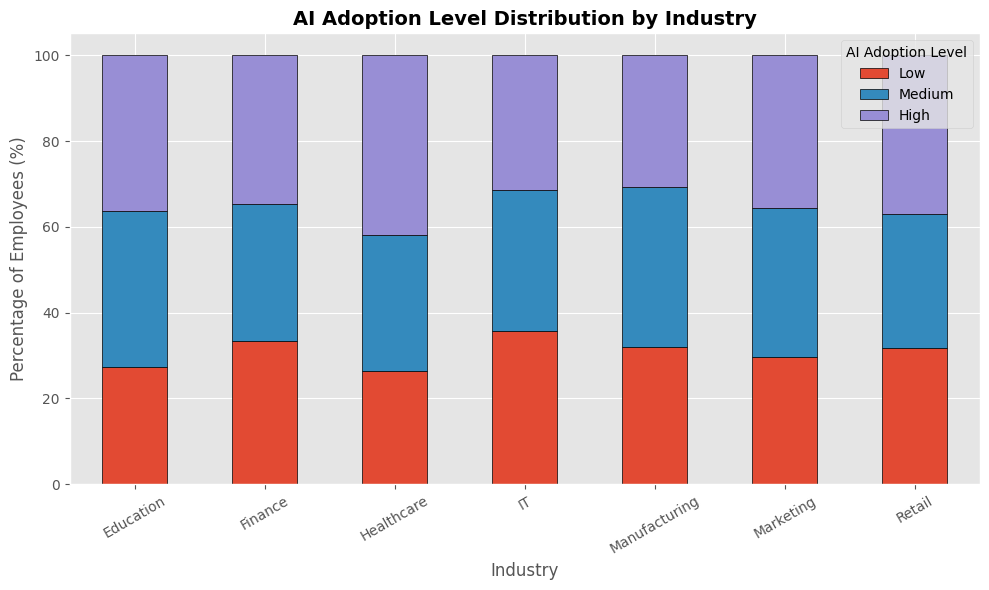

In [ ]:
#1A: How is AI adoption distributed across different industries
# Percentage distribution of AI Adoption by Industry
industry_percent = (
    pd.crosstab(
        df["Industry"],
        df["AI_Adoption_Level"],
        normalize="index"
    ) * 100
).round(1)

# Order the AI Adoption Level
industry_percent = industry_percent[["Low", "Medium", "High"]]

# Plot
ax = industry_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    edgecolor="black"
)

plt.title("AI Adoption Level Distribution by Industry", fontsize=14, fontweight="bold")
plt.xlabel("Industry")
plt.ylabel("Percentage of Employees (%)")
plt.legend(title="AI Adoption Level")
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

In [ ]:
#1B: How is AI adoption distributed across different Job Roles
# Percentage distribution of AI Adoption by Job Roles
top5_high = (
    pd.crosstab(
        df["Job_Role"],
        df["AI_Adoption_Level"],
        normalize="index"
    )
    .mul(100)
    .round(2)[["High"]]
    .sort_values(by="High", ascending=False)
    .head(5)
)

top5_high["High"] = top5_high["High"].map("{:.2f}%".format)

top5_high

AI_Adoption_Level,High
Job_Role,
Doctor,47.06%
Teacher,45.00%
Sales Associate,42.50%
Data Analyst,41.07%
Store Manager,40.95%


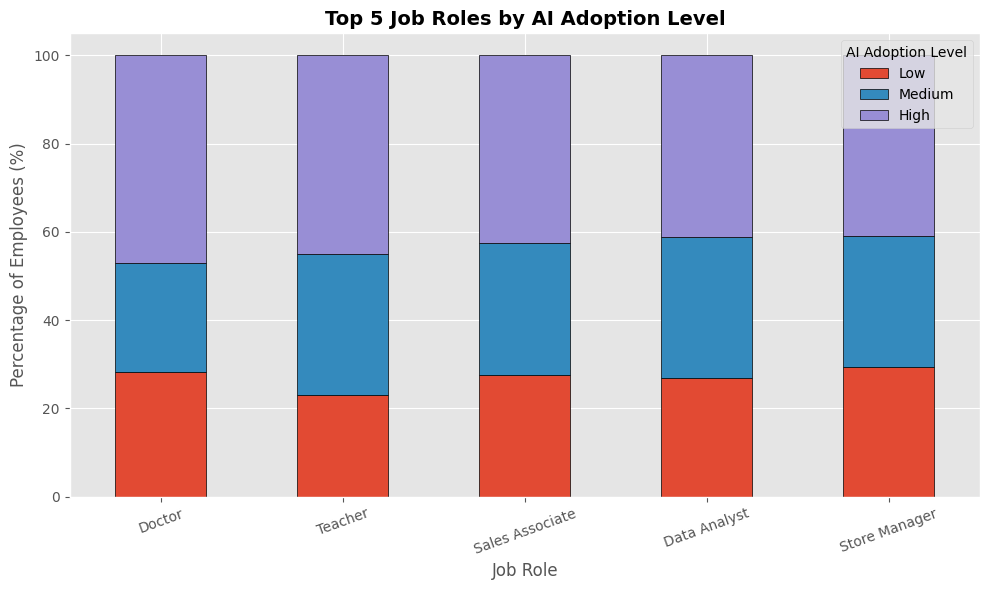

In [ ]:
#1B: How is AI adoption distributed across different Job Roles
# Calculate percentage distribution
jobrole_percent = (
    pd.crosstab(
        df["Job_Role"],
        df["AI_Adoption_Level"],
        normalize="index"
    ) * 100
).round(1)

# Reorder columns
jobrole_percent = jobrole_percent[["Low", "Medium", "High"]]

# Select Top 5 Job Roles based on High AI Adoption
top5_jobrole = jobrole_percent.sort_values(
    by="High",
    ascending=False
).head(5)

# Plot
ax = top5_jobrole.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    edgecolor="black"
)

plt.title("Top 5 Job Roles by AI Adoption Level", fontsize=14, fontweight="bold")
plt.xlabel("Job Role")
plt.ylabel("Percentage of Employees (%)")
plt.legend(title="AI Adoption Level")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

###**Q2: Does AI adoption show a relationship with employee productivity?**




In [28]:
#2A :  Descriptive Analytics
# Descriptive Statistics
productivity_summary = (
    df.groupby("AI_Adoption_Level")["Productivity_Change_%"]
      .agg(
          Count="count",
          Mean="mean",
          Median="median",
          Std="std",
          Minimum="min",
          Maximum="max"
      )
      .round(2)
)

productivity_summary

,Count,Mean,Median,Std,Minimum,Maximum
AI_Adoption_Level,,,,,,
High,705,10.96,12.0,17.02,-20,40
Low,618,8.05,7.0,17.20,-20,40
Medium,677,10.17,10.0,17.29,-20,40


<Figure size 800x600 with 0 Axes>

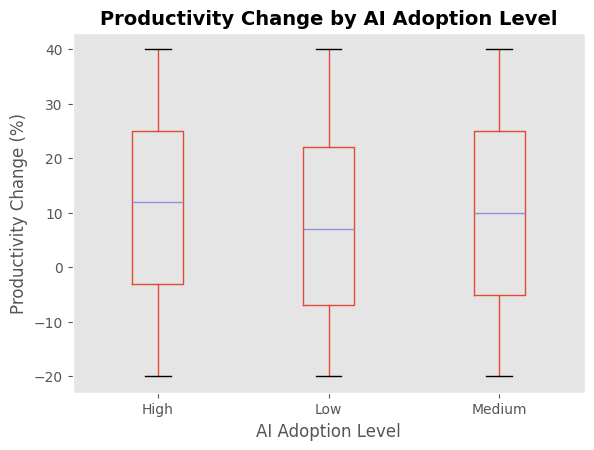

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

df.boxplot(
    column="Productivity_Change_%",
    by="AI_Adoption_Level",
    grid=False
)

plt.title("Productivity Change by AI Adoption Level", fontsize=14, fontweight="bold")
plt.suptitle("")
plt.xlabel("AI Adoption Level")
plt.ylabel("Productivity Change (%)")

plt.show()

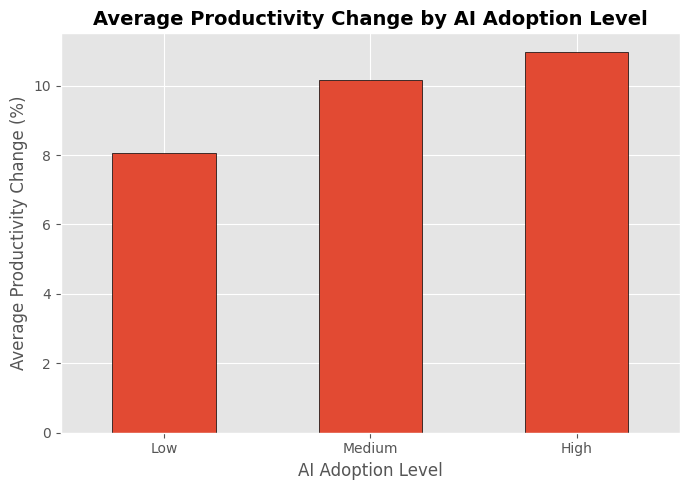

In [31]:
mean_productivity = (
    df.groupby("AI_Adoption_Level")["Productivity_Change_%"]
      .mean()
      .reindex(["Low","Medium","High"])
)

plt.figure(figsize=(7,5))

mean_productivity.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Average Productivity Change by AI Adoption Level", fontsize=14, fontweight="bold")
plt.xlabel("AI Adoption Level")
plt.ylabel("Average Productivity Change (%)")
plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

In [32]:
from scipy.stats import f_oneway

low = df[df["AI_Adoption_Level"]=="Low"]["Productivity_Change_%"]
medium = df[df["AI_Adoption_Level"]=="Medium"]["Productivity_Change_%"]
high = df[df["AI_Adoption_Level"]=="High"]["Productivity_Change_%"]

f_stat, p_value = f_oneway(low, medium, high)

print(f"F-statistic : {f_stat:.4f}")
print(f"P-value     : {p_value:.4f}")

F-statistic : 4.9780
P-value     : 0.0070


In [33]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
    print("There is a statistically significant difference in productivity across AI Adoption Levels.")
else:
    print("Fail to Reject H0")
    print("No statistically significant difference was found.")

Reject H0
There is a statistically significant difference in productivity across AI Adoption Levels.


###**Q3: How does AI adoption influence employee job satisfaction and work efficiency?**




In [35]:
summary_q3 = (
    df.groupby("AI_Adoption_Level")
      .agg({
          "Job_Satisfaction": ["mean", "median", "std"],
          "Work_Efficiency_Score": ["mean", "median", "std"]
      })
      .round(2)
)

summary_q3

Job_Satisfaction              Work_Efficiency_Score         \
                              mean median   std                  mean median   
AI_Adoption_Level                                                              
High                          6.03    6.0  2.05                  0.71   0.71   
Low                           6.05    6.0  1.99                  0.63   0.60   
Medium                        5.99    6.0  1.98                  0.68   0.67   

                         
                    std  
AI_Adoption_Level        
High               0.41  
Low                0.40  
Medium             0.40

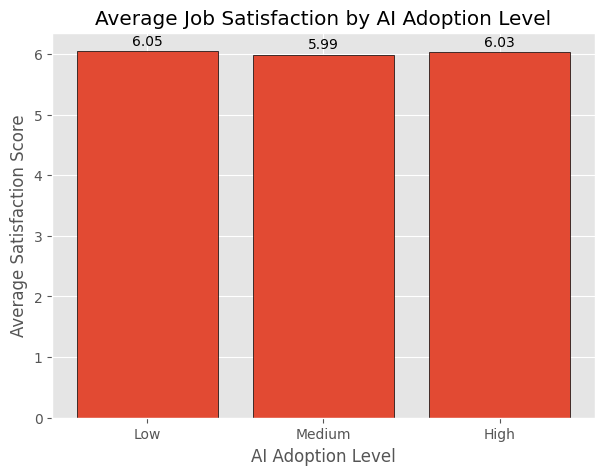

In [36]:
job_sat = (
    df.groupby("AI_Adoption_Level")["Job_Satisfaction"]
      .mean()
      .reindex(["Low", "Medium", "High"])
)

plt.figure(figsize=(7,5))

bars = plt.bar(
    job_sat.index,
    job_sat.values,
    edgecolor="black"
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.1,
        f"{bar.get_height():.2f}",
        ha="center"
    )

plt.title("Average Job Satisfaction by AI Adoption Level")
plt.xlabel("AI Adoption Level")
plt.ylabel("Average Satisfaction Score")

plt.show()

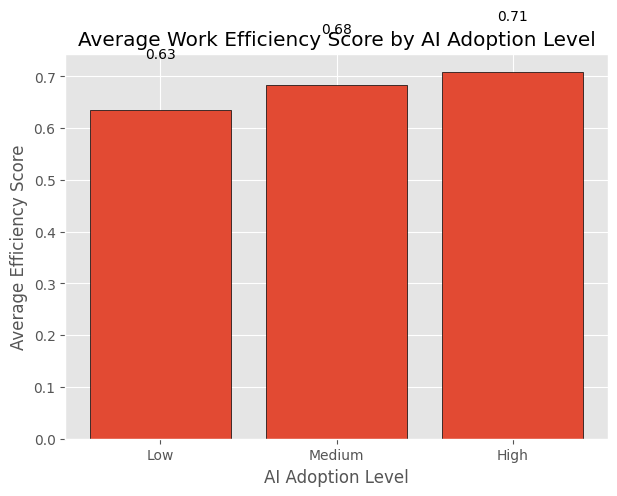

In [37]:
eff = (
    df.groupby("AI_Adoption_Level")["Work_Efficiency_Score"]
      .mean()
      .reindex(["Low", "Medium", "High"])
)

plt.figure(figsize=(7,5))

bars = plt.bar(
    eff.index,
    eff.values,
    edgecolor="black"
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.1,
        f"{bar.get_height():.2f}",
        ha="center"
    )

plt.title("Average Work Efficiency Score by AI Adoption Level")
plt.xlabel("AI Adoption Level")
plt.ylabel("Average Efficiency Score")

plt.show()

In [38]:
from scipy.stats import f_oneway

low = df[df["AI_Adoption_Level"] == "Low"]["Job_Satisfaction"]
medium = df[df["AI_Adoption_Level"] == "Medium"]["Job_Satisfaction"]
high = df[df["AI_Adoption_Level"] == "High"]["Job_Satisfaction"]

f_stat, p_value = f_oneway(low, medium, high)

print(f"F-statistic : {f_stat:.4f}")
print(f"P-value     : {p_value:.4f}")

F-statistic : 0.1571
P-value     : 0.8547


In [40]:
low = df[df["AI_Adoption_Level"] == "Low"]["Work_Efficiency_Score"]
medium = df[df["AI_Adoption_Level"] == "Medium"]["Work_Efficiency_Score"]
high = df[df["AI_Adoption_Level"] == "High"]["Work_Efficiency_Score"]

f_stat, p_value = f_oneway(low, medium, high)

print(f"F-statistic : {f_stat:.4f}")
print(f"P-value     : {p_value:.4f}")

F-statistic : 5.5839
P-value     : 0.0038


###**Q4: Which factors appear to have the strongest influence on workforce productivity?**




In [57]:
# Select numerical variables
corr_df = df[
    [
        "Age",
        "Years_Experience",
        "Salary_Change_%",
        "Work_Hours_Per_Week",
        "Job_Satisfaction",
        "Work_Efficiency_Score",
        "Productivity_Change_%"
    ]
]

# Correlation Matrix
corr_matrix = corr_df.corr()

corr_matrix

,Age,Years_Experience,Salary_Change_%,Work_Hours_Per_Week,Job_Satisfaction,Work_Efficiency_Score,Productivity_Change_%
Age,1.000000,0.991465,-0.002459,0.029189,-0.019276,0.002475,0.011692
Years_Experience,0.991465,1.000000,-0.008958,0.032380,-0.015782,-0.003296,0.007011
Salary_Change_%,-0.002459,-0.008958,1.000000,0.045294,0.016252,0.012802,0.025810
Work_Hours_Per_Week,0.029189,0.032380,0.045294,1.000000,0.003628,-0.247095,-0.028589
Job_Satisfaction,-0.019276,-0.015782,0.016252,0.003628,1.000000,-0.015380,-0.013038
Work_Efficiency_Score,0.002475,-0.003296,0.012802,-0.247095,-0.015380,1.000000,0.966890
Productivity_Change_%,0.011692,0.007011,0.025810,-0.028589,-0.013038,0.966890,1.000000


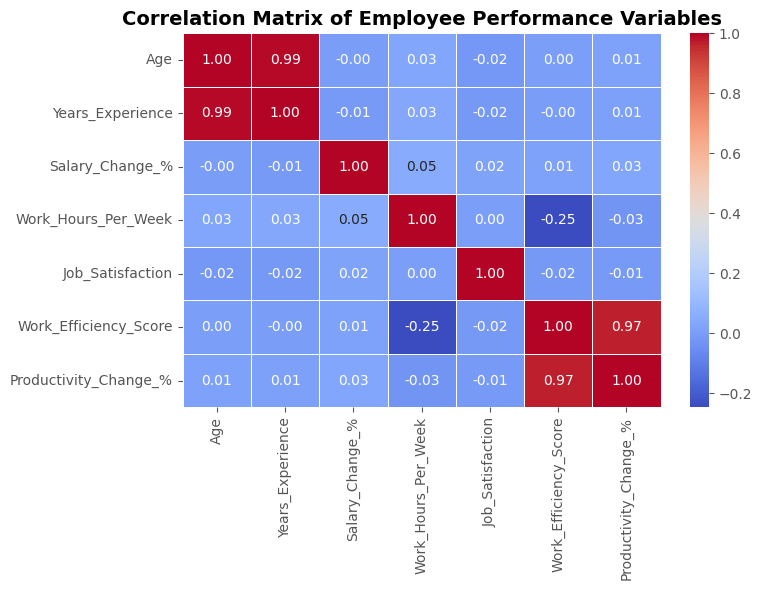

In [58]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=.5
)

plt.title("Correlation Matrix of Employee Performance Variables",
          fontsize=14,
          fontweight="bold")

plt.tight_layout()
plt.show()

In [59]:
# Correlation with Productivity
corr_productivity = (
    corr_matrix["Productivity_Change_%"]
    .drop("Productivity_Change_%")
    .sort_values(ascending=False)
)

corr_productivity

,Productivity_Change_%
Work_Efficiency_Score,0.966890
Salary_Change_%,0.025810
Age,0.011692
Years_Experience,0.007011
Job_Satisfaction,-0.013038
Work_Hours_Per_Week,-0.028589


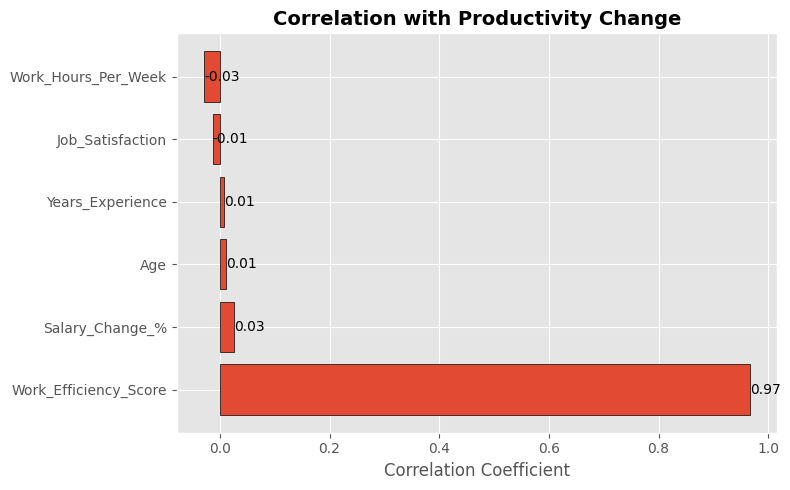

In [60]:
plt.figure(figsize=(8,5))

bars = plt.barh(
    corr_productivity.index,
    corr_productivity.values,
    edgecolor="black"
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y()+bar.get_height()/2,
        f"{width:.2f}",
        va="center",
        fontsize=10
    )

plt.title("Correlation with Productivity Change",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Correlation Coefficient")

plt.tight_layout()

plt.show()

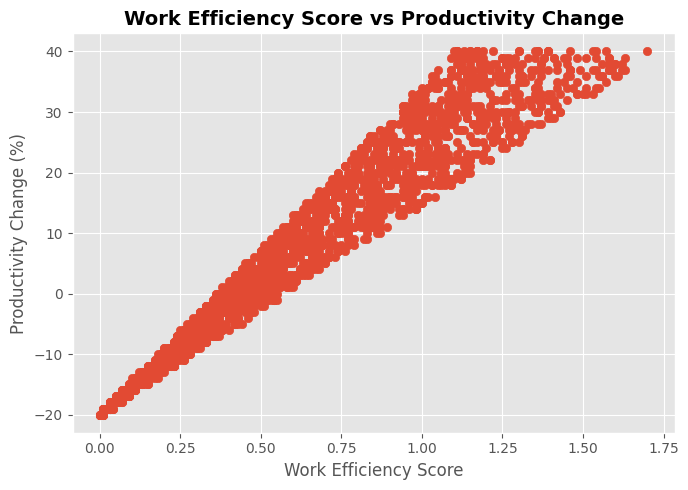

In [61]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["Work_Efficiency_Score"],
    df["Productivity_Change_%"]
)

plt.title("Work Efficiency Score vs Productivity Change",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Work Efficiency Score")
plt.ylabel("Productivity Change (%)")

plt.tight_layout()

plt.show()